In [25]:
import os, random, numpy as np, tensorflow as tf

os.environ["PYTHONHASHSEED"] = "0"
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)


In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_dir = "dataset/chest_xray/chest_xray"   # change if needed
trainval_dir = os.path.join(base_dir, "train")  # we'll also include val manually below
val_dir_kaggle = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")


In [27]:
img_size = (150, 150)
batch_size = 32
seed = 123

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,     # our real val split
    rotation_range=5,
    width_shift_range=0.02,
    height_shift_range=0.02,
    zoom_range=0.05,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    trainval_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    seed=seed,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    trainval_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    seed=seed,
    shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

print("Train counts:", np.bincount(train_generator.classes))
print("Val counts:", np.bincount(val_generator.classes))
print("Test counts:", np.bincount(test_generator.classes))
print("Class indices:", train_generator.class_indices)


Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train counts: [1073 3100]
Val counts: [268 775]
Test counts: [234 390]
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [28]:
from tensorflow.keras import layers, models

def build_model():
    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),
        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


In [29]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]


## Traing without class weights

In [30]:
tf.keras.backend.clear_session()
model_a = build_model()

history_a = model_a.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 247ms/step - accuracy: 0.7779 - loss: 0.5196 - val_accuracy: 0.8696 - val_loss: 0.3289
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 232ms/step - accuracy: 0.9195 - loss: 0.2081 - val_accuracy: 0.9195 - val_loss: 0.2330
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 30s 232ms/step - accuracy: 0.9295 - loss: 0.1970 - val_accuracy: 0.9396 - val_loss: 0.1532
Epoch 4/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 237ms/step - accuracy: 0.9346 - loss: 0.1636 - val_accuracy: 0.9549 - val_loss: 0.1360
Epoch 5/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 236ms/step - accuracy: 0.9494 - loss: 0.1285 - val_accuracy: 0.9540 - val_loss: 0.1468
Epoch 6/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 238ms/step - accuracy: 0.9514 - loss: 0.1411 - val_accuracy: 0.9559 - val_loss: 0.1166
Epoch 7/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - accuracy: 0.9547 - loss: 0.1198 - val_accuracy: 0.9540 - val_loss: 0.1335
Epoch 8/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 235ms/step - accuracy: 0.9593 - loss: 0

## Train with class weights

In [31]:
counts = np.bincount(train_generator.classes)
total = counts.sum()

class_weight = {
    0: total / (2 * counts[0]),
    1: total / (2 * counts[1])
}
print("Class weights:", class_weight)


Class weights: {0: 1.9445479962721341, 1: 0.6730645161290323}


In [32]:
tf.keras.backend.clear_session()
model_b = build_model()

history_b = model_b.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=callbacks
)


Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 32s 240ms/step - accuracy: 0.3949 - loss: 2.1149 - val_accuracy: 0.6673 - val_loss: 0.8034
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 233ms/step - accuracy: 0.5550 - loss: 0.9973 - val_accuracy: 0.6203 - val_loss: 0.8046
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 224ms/step - accuracy: 0.6727 - loss: 1.0481 - val_accuracy: 0.8140 - val_loss: 0.5129


## Compare both models on test set

In [59]:
from utils import evaluate


In [ ]:
results = []

results.append(evaluate(
    model_a,
    name="No class weights",
    flip=True,
    class_weights=False
))

results.append(evaluate(
    model_b,
    name="With class weights",
    flip=True,
    class_weights=True
))


=== No class weights @ threshold 0.500 ===
[[ 92 142]
 [  3 387]]
              precision    recall  f1-score   support

      NORMAL       0.97      0.39      0.56       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.69      0.70       624
weighted avg       0.82      0.77      0.74       624

Macro F1: 0.7007451604261272
Weighted F1: 0.7361138213533277

=== With class weights @ threshold 0.500 ===
[[ 27 207]
 [ 57 333]]
              precision    recall  f1-score   support

      NORMAL       0.32      0.12      0.17       234
   PNEUMONIA       0.62      0.85      0.72       390

    accuracy                           0.58       624
   macro avg       0.47      0.48      0.44       624
weighted avg       0.51      0.58      0.51       624

Macro F1: 0.44297017650639076
Weighted F1: 0.5112598904443092


- Introducing class weights reduced prediction biased towards the pneumonia class (majority class from training data)
- Improved macro f1 score from 0.62 to 0.70 and increased normal-case recall while preserving high sensitivity for pneumonia cases

## Data Augmentation
- Change horozontal flip = False
- This is important because, although we are creating more images with augmentaiton and giving model more training data with the horizontal flip, medical images have significant effect on this.
As we can see from the x-ray images, there are marks of R in the top left which means the heart is on the right side and that is the real way x-rays are looked upon. Thus, if we flip the image, the heart will be on the wrong side, white spots on the left lungs will be on the right lung (which should not matter because it is pneumonia anyway). In real life, doctors perceive the flipped x-ray image as wrong x-ray.

In [34]:
img_size = (150, 150)
batch_size = 32
seed = 123

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,     # our real val split
    rotation_range=5,
    width_shift_range=0.02,
    height_shift_range=0.02,
    zoom_range=0.05,
    brightness_range=(0.9, 1.1),
    horizontal_flip=False # changed here
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    trainval_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="training",
    seed=seed,
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    trainval_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    subset="validation",
    seed=seed,
    shuffle=False
)

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False
)

print("Train counts:", np.bincount(train_generator.classes))
print("Val counts:", np.bincount(val_generator.classes))
print("Test counts:", np.bincount(test_generator.classes))
print("Class indices:", train_generator.class_indices)



Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
Train counts: [1073 3100]
Val counts: [268 775]
Test counts: [234 390]
Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [35]:
tf.keras.backend.clear_session()
model_c = build_model()

history_c = model_c.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=callbacks
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 229ms/step - accuracy: 0.7711 - loss: 0.5804 - val_accuracy: 0.8754 - val_loss: 0.4281
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.9310 - loss: 0.1842 - val_accuracy: 0.9348 - val_loss: 0.1843
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.9442 - loss: 0.1402 - val_accuracy: 0.9521 - val_loss: 0.1354


In [36]:
tf.keras.backend.clear_session()
model_d = build_model()

history_d = model_d.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    class_weight=class_weight,
    callbacks=callbacks
)

Epoch 1/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 31s 232ms/step - accuracy: 0.8176 - loss: 0.4024 - val_accuracy: 0.9348 - val_loss: 0.2013
Epoch 2/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 222ms/step - accuracy: 0.9401 - loss: 0.1664 - val_accuracy: 0.9300 - val_loss: 0.2177
Epoch 3/30
131/131 ━━━━━━━━━━━━━━━━━━━━ 29s 223ms/step - accuracy: 0.9475 - loss: 0.1448 - val_accuracy: 0.9252 - val_loss: 0.2274


In [50]:
results = []

results.append(evaluate(
    model_a,
    name="No class weights, flip=True",
    flip=True,
    class_weights=False
))

results.append(evaluate(
    model_b,
    name="With class weights , flip=True",
    flip=True,
    class_weights=True
))

results.append(evaluate(
    model_c,
    name="No class weights, flip=False",
    flip=False,
    class_weights=False
))

results.append(evaluate(
    model_d,
    name="With class weights , flip=False",
    flip=False,
    class_weights=True
))




=== No class weights, flip=True @ threshold 0.500 ===
[[ 92 142]
 [  3 387]]
              precision    recall  f1-score   support

      NORMAL       0.97      0.39      0.56       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.77       624
   macro avg       0.85      0.69      0.70       624
weighted avg       0.82      0.77      0.74       624

Macro F1: 0.7007451604261272
Weighted F1: 0.7361138213533277

=== With class weights , flip=True @ threshold 0.500 ===
[[ 27 207]
 [ 57 333]]
              precision    recall  f1-score   support

      NORMAL       0.32      0.12      0.17       234
   PNEUMONIA       0.62      0.85      0.72       390

    accuracy                           0.58       624
   macro avg       0.47      0.48      0.44       624
weighted avg       0.51      0.58      0.51       624

Macro F1: 0.44297017650639076
Weighted F1: 0.5112598904443092

=== No class weights, flip=False @ threshold 0.500 ===
[[141  9

In [51]:
import pandas as pd

df = pd.DataFrame(results)
df_rounded = df.round(3)
df_rounded


,Model,Flip,Class Weights,Threshold,AUROC,AUPRC,Accuracy,Macro F1,Weighted F1,Normal Recall,Pneumonia Recall,TN,FP,FN,TP
0,"No class weights, flip=True",True,False,0.5,0.914,0.929,0.768,0.701,0.736,0.393,0.992,92,142,3,387
1,"With class weights , flip=True",True,True,0.5,0.395,0.544,0.577,0.443,0.511,0.115,0.854,27,207,57,333
2,"No class weights, flip=False",False,False,0.5,0.882,0.926,0.792,0.764,0.784,0.603,0.905,141,93,37,353
3,"With class weights , flip=False",False,True,0.5,0.928,0.952,0.814,0.779,0.801,0.556,0.969,130,104,12,378


Disabling horizontal flipping preserved anatomical consistency and improved balanced performance. Introducing class weights further reduced false negatives, making the model more suitable for assistive pneumonia screening.

## Tuning the threshold


In [52]:
from utils import eval_thresholds


In [53]:
thresholds = np.linspace(0.2, 0.95, 13)
df_thresh = eval_thresholds(model=model_d, generator=test_generator, thresholds=thresholds)
df_thresh


,Threshold,Accuracy,Macro F1,Weighted F1,Normal Recall,Pneumonia Recall,FN,FP
0,0.200,0.760,0.689,0.726,0.376,0.990,4,146
1,0.262,0.769,0.707,0.741,0.410,0.985,6,138
2,0.325,0.782,0.730,0.760,0.457,0.977,9,127
3,0.388,0.787,0.739,0.767,0.479,0.972,11,122
4,0.450,0.801,0.760,0.785,0.517,0.972,11,113
5,0.512,0.814,0.779,0.801,0.556,0.969,12,104
6,0.575,0.825,0.796,0.815,0.594,0.964,14,95
7,0.638,0.837,0.811,0.829,0.628,0.962,15,87
8,0.700,0.851,0.831,0.845,0.675,0.956,17,76
9,0.762,0.857,0.840,0.853,0.701,0.951,19,70


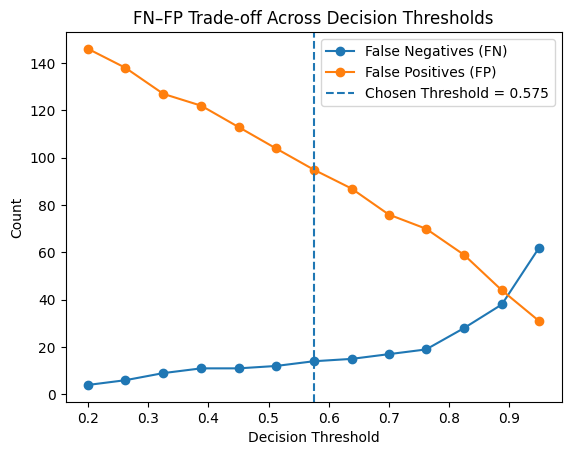

In [54]:
import matplotlib.pyplot as plt

chosen_threshold = 0.575

plt.figure()
plt.plot(df_thresh["Threshold"], df_thresh["FN"], marker="o", label="False Negatives (FN)")
plt.plot(df_thresh["Threshold"], df_thresh["FP"], marker="o", label="False Positives (FP)")

# Vertical line for selected threshold
plt.axvline(x=chosen_threshold, linestyle="--", label="Chosen Threshold = 0.575")

plt.xlabel("Decision Threshold")
plt.ylabel("Count")
plt.title("FN–FP Trade-off Across Decision Thresholds")
plt.legend()
plt.show()


- AT lower thresholds(<0.32), pneumonia recall is great but normal recall is poor and fp is very high as well, which means there are too many false alarms (normals are treated as pneumonia)
- In the middle range(0.38-0.52), keeps FN low, improves normal recall steadily. Sensible results 
- For higher thresholds (>0.70), accuracy is steadily good, improves normall recall but pneumonia recall also drops slowly, while FN climbs slowly.
- The decision threshold was tuned on the validation set to balance sensitivity and false positives. Lower thresholds achieved very high pneumonia recall but produced excessive false alarms, while higher thresholds reduced false positives at the cost of missing more pneumonia cases. A threshold of 0.575 was selected as a balanced operating point, maintaining high pneumonia recall (≈0.96) while significantly reducing false positives.
- Although higher thresholds achieved marginally better accuracy and F1 scores, they did so at the expense of a rapid increase in false negatives. The threshold of 0.575 represents an optimal screening operating point, maintaining high pneumonia sensitivity (96.4%) while substantially reducing false positives compared to lower thresholds. Beyond this point, reductions in false positives are accompanied by a disproportionate loss in sensitivity, increasing the risk of missed pneumonia cases. Given the higher clinical cost of false negatives, 0.575 was selected as the operating threshold.


### PR Curve

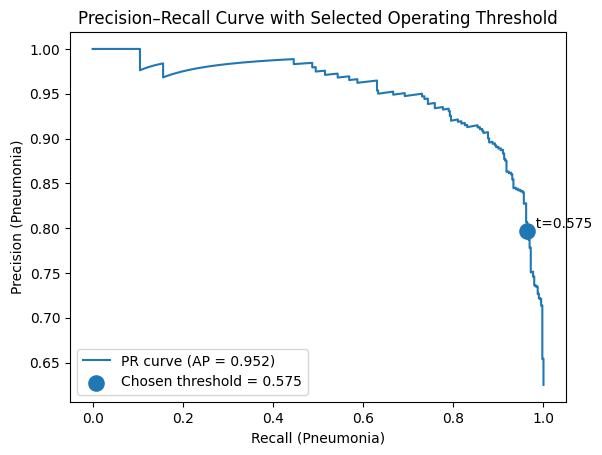

In [55]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

final_model = model_d  # model with class weights and no flip
# Get probabilities on test set
test_generator.reset()
probs = final_model.predict(test_generator, verbose=0).ravel()
y_true = test_generator.classes

# Compute Precision–Recall curve
precision, recall, thresholds = precision_recall_curve(y_true, probs)
ap = average_precision_score(y_true, probs)

# Chosen threshold
chosen_threshold = 0.575

# Find index of threshold closest to chosen_threshold
idx = np.argmin(np.abs(thresholds - chosen_threshold))

# Plot PR curve
plt.figure()
plt.plot(recall, precision, label=f"PR curve (AP = {ap:.3f})")

# Mark chosen threshold point
plt.scatter(
    recall[idx],
    precision[idx],
    s=120,
    label=f"Chosen threshold = {chosen_threshold}"
)
plt.text(
    recall[idx],
    precision[idx],
    f"  t={chosen_threshold}",
    verticalalignment="bottom"
)

plt.xlabel("Recall (Pneumonia)")
plt.ylabel("Precision (Pneumonia)")
plt.title("Precision–Recall Curve with Selected Operating Threshold")
plt.legend()
plt.show()


The operating threshold was selected based on the precision–recall trade-off shown in Figure. A threshold of 0.575 corresponds to a high-recall region of the curve (≈95% sensitivity) while maintaining acceptable precision (≈80%). Compared to lower thresholds, which yield marginal gains in recall at the cost of a sharp drop in precision, this operating point avoids an excessive increase in false positives. Conversely, higher thresholds improve precision only modestly but result in a disproportionate loss in recall, increasing the risk of missed pneumonia cases. Given the higher clinical cost associated with false negatives in pneumonia screening, the threshold of 0.575 provides a balanced and clinically appropriate trade-off between sensitivity and precision

In [46]:
print(test_generator.class_indices)


{'NORMAL': 0, 'PNEUMONIA': 1}


In [47]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc = roc_auc_score(y_true, probs)
pr_auc  = average_precision_score(y_true, probs)


In [61]:
baseline_model = model_d  # model with class weights and no flip
# Evaluate baseline CNN at its chosen screening threshold
baseline_screen_res = evaluate(
    baseline_model,
    test_generator,
    name="Baseline CNN",
    threshold=0.575,
    flip=False,
    class_weights=False
)

# Add metadata for summary tables
baseline_screen_res["Mode"] = "Screening"
baseline_screen_res["Params"] = baseline_model.count_params()

baseline_screen_res



=== Baseline CNN @ threshold 0.575 ===
[[139  95]
 [ 14 376]]
              precision    recall  f1-score   support

      NORMAL       0.91      0.59      0.72       234
   PNEUMONIA       0.80      0.96      0.87       390

    accuracy                           0.83       624
   macro avg       0.85      0.78      0.80       624
weighted avg       0.84      0.83      0.82       624

AUROC: 0.9284 | AUPRC: 0.9516
Macro F1: 0.7959 | Weighted F1: 0.8153
Sensitivity: 0.9641 | Specificity: 0.5940 | Precision: 0.7983


{'Model': 'Baseline CNN',
 'Flip': False,
 'Class Weights': False,
 'Threshold': 0.575,
 'AUROC': 0.9283585360508437,
 'AUPRC': 0.9515906369321765,
 'Accuracy': 0.8253205128205128,
 'Macro F1': 0.7958746364872287,
 'Weighted F1': 0.8152567323015424,
 'Sensitivity': 0.9641025641025641,
 'Specificity': 0.594017094017094,
 'Precision': 0.7983014861995754,
 'TN': 139,
 'FP': 95,
 'FN': 14,
 'TP': 376,
 'Mode': 'Screening',
 'Params': 4828481}

In [62]:
from pathlib import Path

out_dir = Path("results")
out_dir.mkdir(exist_ok=True)

pd.DataFrame([baseline_screen_res]).to_csv(
    out_dir / "baseline_results.csv",
    index=False
)
